In [1]:
import os 

base_dir = './data/dream/real'
choice = 'panda-3cam_realsense'
# ['panda-3cam_realsense',
#  'panda-3cam_azure',
#  'panda-3cam_kinect360',
#  'panda-orb']
data_dir = os.path.join(base_dir, choice)

image_lists = sorted([x for x in os.listdir(data_dir) if x.endswith('jpg')])
image_lists

['000000.rgb.jpg',
 '000001.rgb.jpg',
 '000002.rgb.jpg',
 '000003.rgb.jpg',
 '000004.rgb.jpg',
 '000005.rgb.jpg',
 '000006.rgb.jpg',
 '000007.rgb.jpg',
 '000008.rgb.jpg',
 '000009.rgb.jpg',
 '000010.rgb.jpg',
 '000011.rgb.jpg',
 '000012.rgb.jpg',
 '000013.rgb.jpg',
 '000014.rgb.jpg',
 '000015.rgb.jpg',
 '000016.rgb.jpg',
 '000017.rgb.jpg',
 '000018.rgb.jpg',
 '000019.rgb.jpg',
 '000020.rgb.jpg',
 '000021.rgb.jpg',
 '000022.rgb.jpg',
 '000023.rgb.jpg',
 '000024.rgb.jpg',
 '000025.rgb.jpg',
 '000026.rgb.jpg',
 '000027.rgb.jpg',
 '000028.rgb.jpg',
 '000029.rgb.jpg',
 '000030.rgb.jpg',
 '000031.rgb.jpg',
 '000032.rgb.jpg',
 '000033.rgb.jpg',
 '000034.rgb.jpg',
 '000035.rgb.jpg',
 '000036.rgb.jpg',
 '000037.rgb.jpg',
 '000038.rgb.jpg',
 '000039.rgb.jpg',
 '000040.rgb.jpg',
 '000041.rgb.jpg',
 '000042.rgb.jpg',
 '000043.rgb.jpg',
 '000044.rgb.jpg',
 '000045.rgb.jpg',
 '000046.rgb.jpg',
 '000047.rgb.jpg',
 '000048.rgb.jpg',
 '000049.rgb.jpg',
 '000050.rgb.jpg',
 '000051.rgb.jpg',
 '000052.rgb

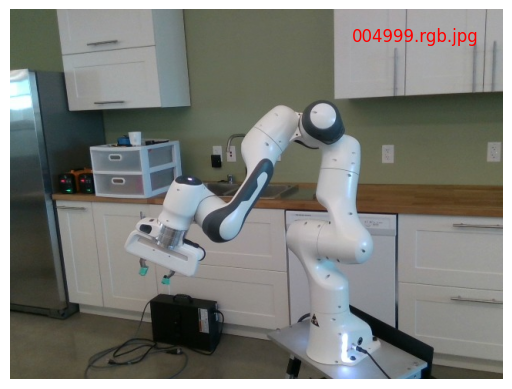

In [19]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import clear_output
import time

base_dir = './data/dream/real'
choice = 'panda-3cam_realsense'  # 可以更换成其他选项
data_dir = os.path.join(base_dir, choice)

# 获取所有jpg文件并排序
image_lists = [x for x in os.listdir(data_dir) if x.endswith('jpg')]
print(len(image_lists))
time.sleep(3)
# 遍历每个图像，显示并清空输出
for image_name in image_lists[:5000]:
    image_path = os.path.join(data_dir, image_name)
    
    # 清空之前的输出
    clear_output(wait=True)
    
    # 读取并显示图像
    img = mpimg.imread(image_path)
    fig, ax = plt.subplots()
    ax.imshow(img)
    
    # 在图像的右上角添加文字
    ax.text(0.95, 0.95, image_name, color='red', fontsize=12, ha='right', va='top', transform=ax.transAxes)
    
    # 关闭坐标轴
    ax.axis('off')
    
    # 显示图像
    plt.show()



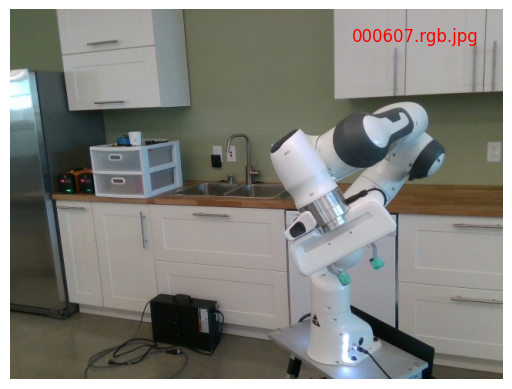

KeyboardInterrupt: 

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import clear_output
import time

# 启用interactive模式
plt.ion()

base_dir = './data/dream/real'
choice = 'panda-3cam_realsense'  # 可以更换成其他选项
data_dir = os.path.join(base_dir, choice)

# 获取所有jpg文件并排序
image_lists = sorted([x for x in os.listdir(data_dir) if x.endswith('jpg')])
print(len(image_lists))
time.sleep(1)

# 遍历每个图像，显示并清空输出
for image_name in image_lists:
    image_path = os.path.join(data_dir, image_name)
    
    # 读取并显示图像
    img = mpimg.imread(image_path)
    fig, ax = plt.subplots()
    ax.imshow(img)
    
    # 在图像的右上角添加文字
    ax.text(0.95, 0.95, image_name, color='red', fontsize=12, ha='right', va='top', transform=ax.transAxes)
    
    # 关闭坐标轴
    ax.axis('off')
    
    # 显示图像
    plt.draw()  # 刷新当前图像
    plt.pause(0.01)  # 短暂的暂停，让交互模式工作
    
    # 清空输出
    clear_output(wait=True)

# 关闭interactive模式
plt.ioff()


In [33]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import json
from IPython.display import clear_output
import time

# 启用interactive模式
plt.ion()

base_dir = './data/dream/real'
choice = 'panda-3cam_realsense'  # 可以更换成其他选项
data_dir = os.path.join(base_dir, choice)

# 获取所有jpg文件并排序
image_lists = sorted([x for x in os.listdir(data_dir) if x.endswith('jpg')])
print(len(image_lists))
time.sleep(1)

# 遍历每个图像，显示并清空输出
for image_name in image_lists[700:]:
    image_path = os.path.join(data_dir, image_name)
    json_path = image_path.replace('.rgb.jpg', '.json')  # 假设json文件与jpg文件同名
    
    # 读取图像
    img = mpimg.imread(image_path)
    
    # 读取对应的JSON文件
    with open(json_path, 'r') as f:
        json_data = json.load(f)
    
    # 创建图像
    fig, ax = plt.subplots()
    ax.imshow(img)
    # 在图像的右上角添加文字
    ax.text(0.95, 0.95, image_name, color='red', fontsize=12, ha='right', va='top', transform=ax.transAxes)
    # 绘制keypoints的projected_location点并标注名称
    for obj in json_data['objects']:
        for keypoint in obj['keypoints']:
            proj_loc = keypoint['projected_location']
            name = keypoint['name']
            
            # 绘制粉色点
            ax.plot(proj_loc[0], proj_loc[1], 'o', color='magenta', markersize=5)
            
            if name == 'panda_link7':
                ax.text(proj_loc[0] - 60, proj_loc[1] + 10, 'panda_link7', color='red', fontsize=8, ha='left', va='top')
            
            else:# 添加标注名称
                ax.text(proj_loc[0] + 15, proj_loc[1] + 4, name, color='red', fontsize=8, ha='left', va='top')
    
    # 关闭坐标轴
    ax.axis('off')
    
    # 显示图像
    plt.draw()  # 刷新当前图像
    plt.pause(0.01)  # 短暂的暂停，让交互模式工作
    
    # 清空输出
    clear_output(wait=True)

# 关闭interactive模式
plt.ioff()


KeyboardInterrupt: 

In [10]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import json
from IPython.display import clear_output
import time

# 启用interactive模式
plt.ion()

base_dir = './data/dream/real'
choice = 'panda-3cam_azure'  # 可以更换成其他选项
data_dir = os.path.join(base_dir, choice)

# 获取所有jpg文件并排序
image_lists = sorted([x for x in os.listdir(data_dir) if x.endswith('jpg')])
print(len(image_lists))
time.sleep(1)

# 遍历每个图像，显示并清空输出
for image_name in image_lists[1000:]:
    image_path = os.path.join(data_dir, image_name)
    json_path = image_path.replace('.rgb.jpg', '.json')  # 假设json文件与jpg文件同名
    
    # 读取图像
    img = mpimg.imread(image_path)
    
    # 读取对应的JSON文件
    with open(json_path, 'r') as f:
        json_data = json.load(f)
    
    # 创建图像
    fig, ax = plt.subplots()
    ax.imshow(img)
    # 在图像的右上角添加文字
    ax.text(0.95, 0.95, image_name, color='red', fontsize=12, ha='right', va='top', transform=ax.transAxes)
    # 绘制keypoints的projected_location点并标注名称
    for obj in json_data['objects']:
        for keypoint in obj['keypoints']:
            proj_loc = keypoint['projected_location']
            name = keypoint['name']
            
            # 绘制粉色点
            ax.plot(proj_loc[0], proj_loc[1], 'o', color='magenta', markersize=5)
            
            # if name == 'panda_link7':
                # ax.text(proj_loc[0] - 60, proj_loc[1] + 10, 'panda_link7', color='red', fontsize=8, ha='left', va='top')
            
            # else:# 添加标注名称
            ax.text(proj_loc[0] + 15, proj_loc[1] + 4, name, color='red', fontsize=8, ha='left', va='top')
    
    # 关闭坐标轴
    ax.axis('off')
    
    # 显示图像
    plt.draw()  # 刷新当前图像
    plt.pause(0.01)  # 短暂的暂停，让交互模式工作
    
    # 清空输出
    clear_output(wait=True)

# 关闭interactive模式
plt.ioff()


In [1]:
import os
import json
from tqdm import tqdm
import numpy as np
# from lib.dataset.const import KEYPOINT_NAMES
# 定义路径
base_dir_real = './data/dream/real'
choices_real = ['panda-3cam_azure', 'panda-3cam_kinect360', 'panda-3cam_realsense', 'panda-orb']
base_dir_synth = "./data/dream/synthetic"
choices_synth = ["panda_synth_test_photo", "panda_synth_test_dr", "panda_synth_train_dr"]
KEYPOINT_NAMES = {
    "panda": [
        "panda_link0", "panda_link2", "panda_link3", "panda_link4", 
        "panda_link6", "panda_link7", "panda_hand"
    ]
}
# 初始化空列表用于存储每个文件夹的关键点数据
# 初始化空列表用于存储每个文件夹的关键点数据
azure_3dkp = []
kinect_3dkp = []
realsense_3dkp = []
orb_3dkp = []
synth_photo_3dkp = []
synth_dr_3dkp = []
synth_dr_train_3dkp = []
# 加载真实数据集
for choice in choices_real:
    data_dir = os.path.join(base_dir_real, choice)
    
    # 获取所有 JSON 文件列表
    json_lists = sorted([x for x in os.listdir(data_dir) if x.endswith('.json')])
    
    # 初始化当前文件夹的关键点数据列表
    current_keypoints = []
    
    # 遍历每个 JSON 文件
    for json_file in tqdm(json_lists, desc=f"Loading {choice}..."):
        # 构建完整文件路径
        file_path = os.path.join(data_dir, json_file)
        
        try:
            # 加载 JSON 文件
            with open(file_path, 'r') as f:
                data = json.load(f)
            
            # 检查是否存在 'objects' 键
            if 'objects' in data and len(data['objects']) > 0:
                # 提取关键点数据
                keypoints = data['objects'][0]["keypoints"]
                # 只保留 kp["name"] 在 KEYPOINT_NAMES["panda"] 中的关键点
                locations = np.array([kp["location"] for kp in keypoints if kp["name"] in KEYPOINT_NAMES["panda"]])
                
                # 添加到当前文件夹的列表中
                current_keypoints.append(locations)
            else:
                print(f"Warning: 'objects' key missing or empty in file {json_file}")
        except Exception as e:
            print(f"Error loading file {json_file}: {e}")
    
    # 将当前文件夹的关键点数据堆叠成一个 (N, 7, 3) 的 numpy 数组
    if current_keypoints:  # 检查列表是否非空
        current_keypoints = np.stack(current_keypoints, axis=0)
    else:
        print(f"No valid keypoints data found in {choice}.")
        current_keypoints = np.array([])  # 返回空数组
    
    # 根据文件夹名称存储到对应的列表中
    if choice == 'panda-3cam_azure':
        azure_3dkp = current_keypoints
    elif choice == 'panda-3cam_kinect360':
        kinect_3dkp = current_keypoints
    elif choice == 'panda-3cam_realsense':
        realsense_3dkp = current_keypoints
    elif choice == 'panda-orb':
        orb_3dkp = current_keypoints

# 加载合成数据集
for choice in choices_synth:
    data_dir = os.path.join(base_dir_synth, choice)
    
    # 获取所有 JSON 文件列表
    json_lists = sorted([x for x in os.listdir(data_dir) if x.endswith('.json')])
    
    # 初始化当前文件夹的关键点数据列表
    current_keypoints = []
    
    # 遍历每个 JSON 文件
    for json_file in tqdm(json_lists, desc=f"Loading {choice}..."):
        # 构建完整文件路径
        file_path = os.path.join(data_dir, json_file)
        
        try:
            # 加载 JSON 文件
            with open(file_path, 'r') as f:
                data = json.load(f)
            
            # 检查是否存在 'objects' 键
            if 'objects' in data and len(data['objects']) > 0:
                # 提取关键点数据
                keypoints = data['objects'][0]["keypoints"]
                # 只保留 kp["name"] 在 KEYPOINT_NAMES["panda"] 中的关键点
                locations = np.array([kp["location"] for kp in keypoints if kp["name"] in KEYPOINT_NAMES["panda"]])
                
                # 添加到当前文件夹的列表中
                current_keypoints.append(locations)
            else:
                print(f"Warning: 'objects' key missing or empty in file {json_file}")
        except Exception as e:
            print(f"Error loading file {json_file}: {e}")
    
    # 将当前文件夹的关键点数据堆叠成一个 (N, 7, 3) 的 numpy 数组
    if current_keypoints:  # 检查列表是否非空
        current_keypoints = np.stack(current_keypoints, axis=0)
    else:
        print(f"No valid keypoints data found in {choice}.")
        current_keypoints = np.array([])  # 返回空数组
    
    # 根据文件夹名称存储到对应的列表中
    if choice == 'panda_synth_test_photo':
        synth_photo_3dkp = current_keypoints * 0.01
    elif choice == 'panda_synth_test_dr':
        synth_dr_3dkp = current_keypoints * 0.01
    elif choice == 'panda_synth_train_dr':
        synth_dr_train_3dkp = current_keypoints * 0.01

# 打印结果
print("Shape of azure_3dkp:", azure_3dkp.shape if azure_3dkp.size > 0 else "Empty")
print("Shape of kinect_3dkp:", kinect_3dkp.shape if kinect_3dkp.size > 0 else "Empty")
print("Shape of realsense_3dkp:", realsense_3dkp.shape if realsense_3dkp.size > 0 else "Empty")
print("Shape of orb_3dkp:", orb_3dkp.shape if orb_3dkp.size > 0 else "Empty")
print("Shape of synth_photo_3dkp:", synth_photo_3dkp.shape if synth_photo_3dkp.size > 0 else "Empty")
print("Shape of synth_dr_3dkp:", synth_dr_3dkp.shape if synth_dr_3dkp.size > 0 else "Empty")
print("Shape of synth_dr_train_3dkp:", synth_dr_train_3dkp.shape if synth_dr_train_3dkp.size > 0 else "Empty")

Loading panda-3cam_azure...: 100%|██████████| 6395/6395 [00:00<00:00, 15064.22it/s]


Loading panda-3cam_kinect360...: 100%|██████████| 4967/4967 [00:00<00:00, 17764.81it/s]


Loading panda-3cam_realsense...: 100%|██████████| 5945/5945 [00:00<00:00, 17088.70it/s]


Loading panda-orb...: 100%|██████████| 32316/32316 [00:01<00:00, 16426.13it/s]


Loading panda_synth_test_photo...: 100%|██████████| 5999/5999 [00:01<00:00, 5479.98it/s]


Loading panda_synth_test_dr...: 100%|██████████| 5999/5999 [00:02<00:00, 2675.30it/s]


Loading panda_synth_train_dr...: 100%|██████████| 104974/104974 [00:38<00:00, 2756.19it/s]


Shape of azure_3dkp: (6394, 7, 3)
Shape of kinect_3dkp: (4966, 7, 3)
Shape of realsense_3dkp: (5944, 7, 3)
Shape of orb_3dkp: (32315, 7, 3)
Shape of synth_photo_3dkp: (5997, 7, 3)
Shape of synth_dr_3dkp: (5997, 7, 3)
Shape of synth_dr_train_3dkp: (104972, 7, 3)


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# 定义数据集和颜色
datasets = {
    "Azure": azure_3dkp,
    "Kinect": kinect_3dkp,
    "Synth_photo": synth_photo_3dkp,
    "RealSense": realsense_3dkp,
    "ORB": orb_3dkp,
    "Synth_dr": synth_dr_3dkp
}
joint_colors = [
    "red", "green", "blue", "orange", "purple", "brown", "pink"  # 关节1-7的颜色
]

# 创建2x2子图画布
fig = plt.figure(figsize=(20, 16))

# 遍历每个数据集，绘制子图
for idx, (name, data) in enumerate(datasets.items(), 1):
    ax = fig.add_subplot(2, 3, idx, projection='3d')
    
    # --- 绘制每个关节的分布（随机采样500点）---
    for joint in range(7):
        joint_data = data[:, joint, :]  # (N,3)
        # 随机采样避免点太多
        np.random.seed(42)
        sample_indices = np.random.choice(len(joint_data), 4500, replace=False)
        sampled_joint = joint_data[sample_indices]
        ax.scatter(sampled_joint[:,0], sampled_joint[:,1], sampled_joint[:,2],
                   color=joint_colors[joint], s=2, alpha=0.2, depthshade=False,
                   label=f'Joint {joint+1}' if joint==0 else "")
    
    # --- 绘制平均姿态连线（用黑色线连接）---
    mean_pose = np.mean(data, axis=0)  # (7,3)
    x_mean, y_mean, z_mean = mean_pose[:,0], mean_pose[:,1], mean_pose[:,2]
    ax.plot(x_mean, y_mean, z_mean, 
            color='black', linewidth=3, marker='o', markersize=6,
            label='Mean Pose')
    
    # 设置子图标题和坐标轴
    ax.set_xlabel('X', fontsize=10)
    ax.set_ylabel('Y', fontsize=10)
    ax.set_zlabel('Z', fontsize=10)
    ax.set_title(f"{name} Keypoints Distribution", fontsize=14, pad=12)
    # ax.view_init(elev=20, azim=45)  # 初始视角
    ax.view_init(elev=5, azim=75)
    ax.legend(loc='upper right', fontsize=8)

# 调整布局
plt.tight_layout(pad=3.0)

# 启用交互模式（确保在 Jupyter Notebook 或 IDE 中运行）
plt.ion()
plt.show()

NameError: name 'azure_3dkp' is not defined

PCA computing ...
PCA compute done! TSNE!


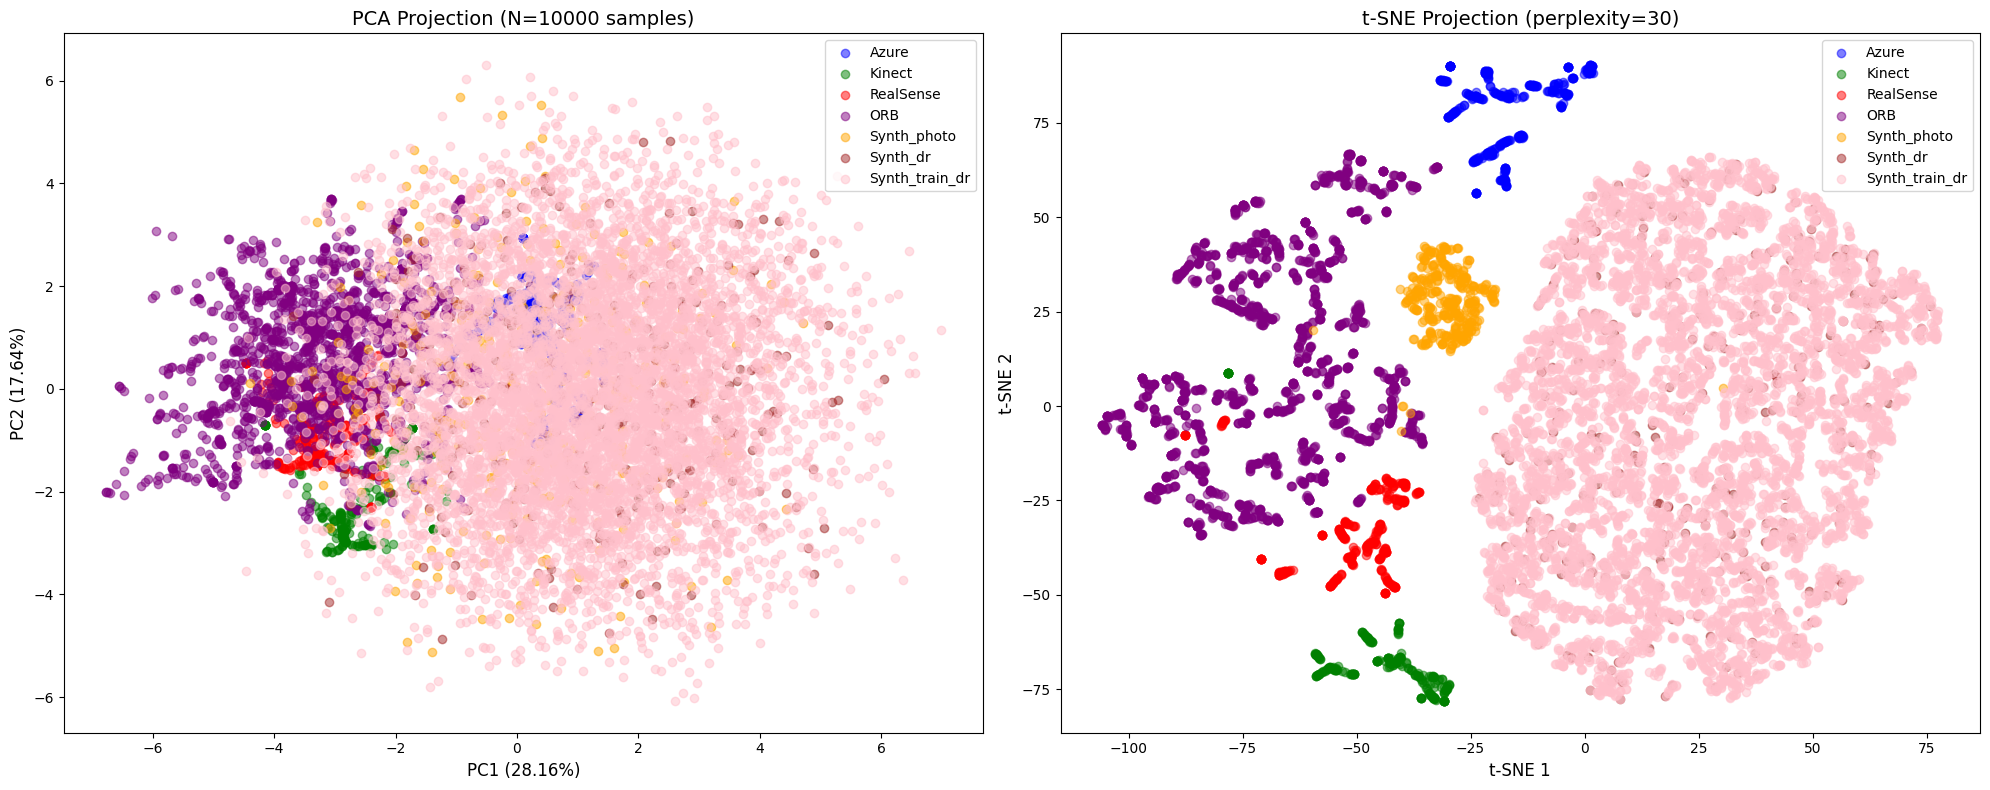

In [2]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 定义数据集和颜色
datasets = {
    "Azure": azure_3dkp,
    "Kinect": kinect_3dkp,
    "RealSense": realsense_3dkp,
    "ORB": orb_3dkp,
    "Synth_photo": synth_photo_3dkp,
    "Synth_dr": synth_dr_3dkp,
    "Synth_train_dr": synth_dr_train_3dkp
}
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'pink']

# 将 (N,7,3) 数据展平为 (N,21) 并合并所有数据集
all_data = []
labels = []
for name, data in datasets.items():
    if data.size == 0:  # 跳过空数据集
        continue
    # 展平数据：每个样本 (7,3) -> (21,)
    flattened_data = data.reshape(data.shape[0], -1)
    all_data.append(flattened_data)
    labels.extend([name] * len(data))

# 合并并标准化数据
X = np.concatenate(all_data, axis=0)
X_scaled = StandardScaler().fit_transform(X)

# 随机采样 1000 个样本
sample_indices = np.random.choice(len(X_scaled), min(10000, len(X_scaled)), replace=False)
X_sampled = X_scaled[sample_indices]
labels_sampled = np.array(labels)[sample_indices]
print("PCA computing ...")
# 设置 n_components 为合法值
n_components = min(50, X_sampled.shape[0], X_sampled.shape[1])
pca_preprocess = PCA(n_components=n_components)
X_pca = pca_preprocess.fit_transform(X_sampled)
print("PCA compute done! TSNE!")
# t-SNE 降维
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, n_jobs=-1)
tsne_result = tsne.fit_transform(X_pca)

# 创建可视化画布
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# 绘制 PCA 结果
unique_labels = list(datasets.keys())
for i, name in enumerate(unique_labels):
    mask = labels_sampled == name
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=colors[i], alpha=0.5, label=name)
ax1.set_title("PCA Projection (N=%d samples)" % len(X_sampled), fontsize=14)
ax1.set_xlabel("PC1 (%.2f%%)" % (pca_preprocess.explained_variance_ratio_[0]*100), fontsize=12)
ax1.set_ylabel("PC2 (%.2f%%)" % (pca_preprocess.explained_variance_ratio_[1]*100), fontsize=12)
ax1.legend(loc='upper right', fontsize=10)

# 绘制 t-SNE 结果
for i, name in enumerate(unique_labels):
    mask = labels_sampled == name
    ax2.scatter(tsne_result[mask, 0], tsne_result[mask, 1], 
                c=colors[i], alpha=0.5, label=name)
ax2.set_title("t-SNE Projection (perplexity=30)", fontsize=14)
ax2.set_xlabel("t-SNE 1", fontsize=12)
ax2.set_ylabel("t-SNE 2", fontsize=12)
ax2.legend(loc='upper right', fontsize=10)

# 调整布局
plt.tight_layout()
plt.show()

PCA computing ...
PCA compute done!
t-SNE computing ...
t-SNE compute done!


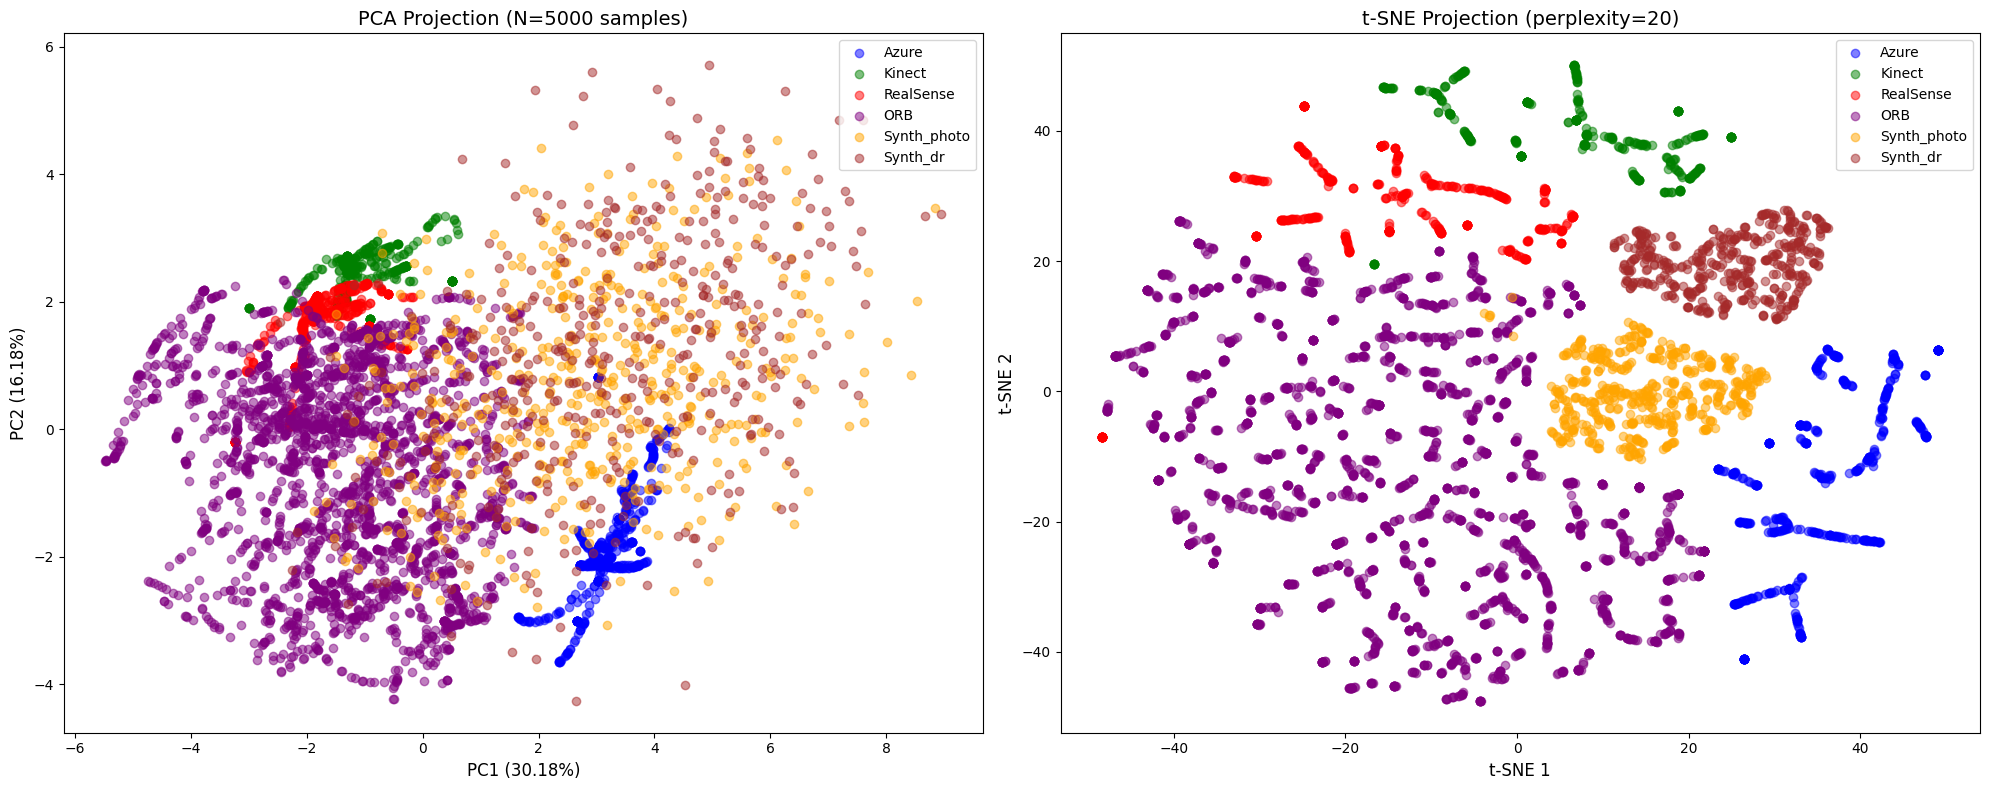

In [12]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 定义数据集和颜色
datasets = {
    "Azure": azure_3dkp,
    "Kinect": kinect_3dkp,
    "RealSense": realsense_3dkp,
    "ORB": orb_3dkp,
    "Synth_photo": synth_photo_3dkp,
    "Synth_dr": synth_dr_3dkp
}
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown']

# 将 (N,7,3) 数据展平为 (N,21) 并合并所有数据集
all_data = []
labels = []
for name, data in datasets.items():
    if data.size == 0:  # 跳过空数据集
        continue
    # 展平数据：每个样本 (7,3) -> (21,)
    flattened_data = data.reshape(data.shape[0], -1)
    all_data.append(flattened_data)
    labels.extend([name] * len(data))

# 合并并标准化数据
X = np.concatenate(all_data, axis=0)
X_scaled = StandardScaler().fit_transform(X)

# 随机采样 4000 个样本
sample_indices = np.random.choice(len(X_scaled), min(5000, len(X_scaled)), replace=False)
X_sampled = X_scaled[sample_indices]
labels_sampled = np.array(labels)[sample_indices]

# 独立运行 PCA
print("PCA computing ...")
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_sampled)
print("PCA compute done!")

# 独立运行 t-SNE
print("t-SNE computing ...")
tsne = TSNE(n_components=2, perplexity=20, n_iter=500, random_state=42, n_jobs=-1)
tsne_result = tsne.fit_transform(X_sampled)
print("t-SNE compute done!")

# 创建可视化画布
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# 绘制 PCA 结果
unique_labels = list(datasets.keys())
for i, name in enumerate(unique_labels):
    mask = labels_sampled == name
    ax1.scatter(pca_result[mask, 0], pca_result[mask, 1], 
                c=colors[i], alpha=0.5, label=name)
ax1.set_title("PCA Projection (N=%d samples)" % len(X_sampled), fontsize=14)
ax1.set_xlabel("PC1 (%.2f%%)" % (pca.explained_variance_ratio_[0]*100), fontsize=12)
ax1.set_ylabel("PC2 (%.2f%%)" % (pca.explained_variance_ratio_[1]*100), fontsize=12)
ax1.legend(loc='upper right', fontsize=10)

# 绘制 t-SNE 结果
for i, name in enumerate(unique_labels):
    mask = labels_sampled == name
    ax2.scatter(tsne_result[mask, 0], tsne_result[mask, 1], 
                c=colors[i], alpha=0.5, label=name)
ax2.set_title("t-SNE Projection (perplexity=20)", fontsize=14)
ax2.set_xlabel("t-SNE 1", fontsize=12)
ax2.set_ylabel("t-SNE 2", fontsize=12)
ax2.legend(loc='upper right', fontsize=10)

# 调整布局
plt.tight_layout()
plt.show()

UMAP computing ...


/home/ruihengwang/miniconda3/envs/hoilistic/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP compute done!


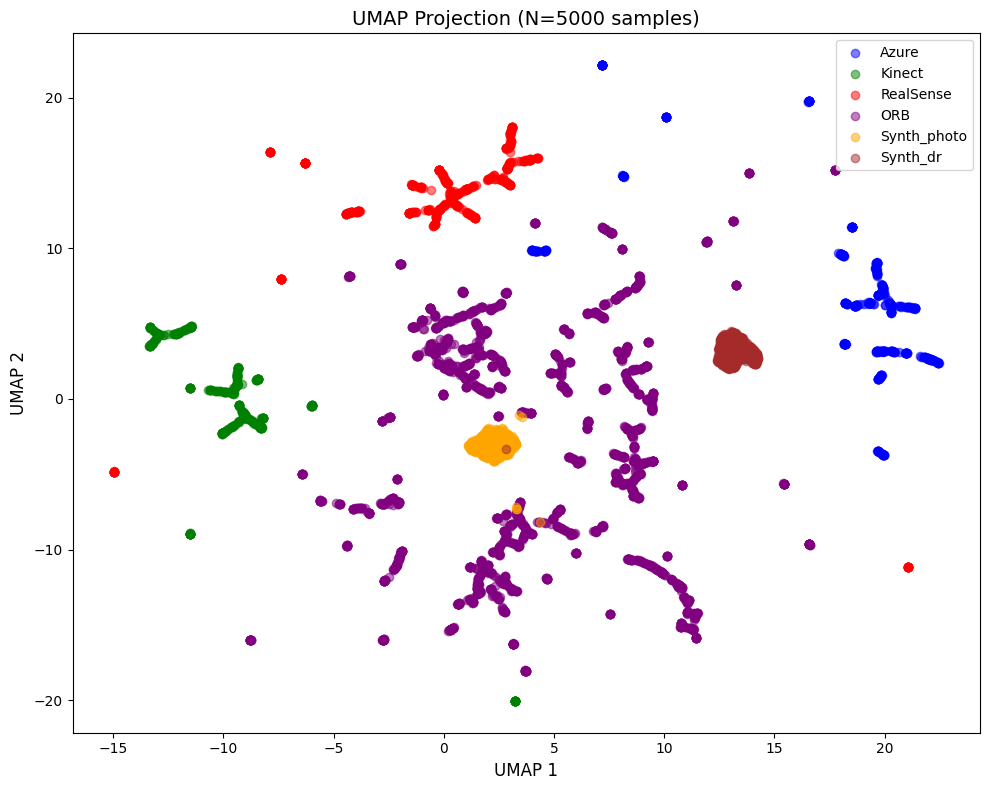

In [17]:

import numpy as np
import umap.umap_ as umap
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 定义数据集和颜色
datasets = {
    "Azure": azure_3dkp,
    "Kinect": kinect_3dkp,
    "RealSense": realsense_3dkp,
    "ORB": orb_3dkp,
    "Synth_photo": synth_photo_3dkp,
    "Synth_dr": synth_dr_3dkp
}
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown']

# 将 (N,7,3) 数据展平为 (N,21) 并合并所有数据集
all_data = []
labels = []
for name, data in datasets.items():
    if data.size == 0:  # 跳过空数据集
        continue
    # 展平数据：每个样本 (7,3) -> (21,)
    flattened_data = data.reshape(data.shape[0], -1)
    all_data.append(flattened_data)
    labels.extend([name] * len(data))

# 合并并标准化数据
X = np.concatenate(all_data, axis=0)
X_scaled = StandardScaler().fit_transform(X)

# 随机采样 1000 个样本
sample_indices = np.random.choice(len(X_scaled), min(5000, len(X_scaled)), replace=False)
X_sampled = X_scaled[sample_indices]
labels_sampled = np.array(labels)[sample_indices]

# 运行 UMAP
print("UMAP computing ...")
umap_reducer = umap.UMAP(n_components=2, random_state=42)
umap_result = umap_reducer.fit_transform(X_sampled)
print("UMAP compute done!")

# 创建可视化画布
plt.figure(figsize=(10, 8))

# 绘制 UMAP 结果
unique_labels = list(datasets.keys())
for i, name in enumerate(unique_labels):
    mask = labels_sampled == name
    plt.scatter(umap_result[mask, 0], umap_result[mask, 1], 
                c=colors[i], alpha=0.5, label=name)
plt.title("UMAP Projection (N=%d samples)" % len(X_sampled), fontsize=14)
plt.xlabel("UMAP 1", fontsize=12)
plt.ylabel("UMAP 2", fontsize=12)
plt.legend(loc='upper right', fontsize=10)

# 调整布局
plt.tight_layout()
plt.show()